# Business Questions

This analysis aims to answer the following business questions and provide actionable insights for sales, profitability, customer behavior, and operational performance.

## Sales Analysis

1. What are the total sales and total profit generated by the business?

2. Which product categories and sub-categories generate the highest and lowest sales?

3. What are the top-performing and worst-performing products based on sales revenue?

4. How do sales and profits change over time across months and quarters?

5. Which regions and states contribute the most and least to overall sales?

## Profitability Analysis

6. Which categories, sub-categories, and products are the most profitable?

7. Are there products with high sales volume but low or negative profitability?

8. What is the relationship between discount rates and profit?

9. Which customer segment generates the highest profit & profit margin?

## Customer Analysis

10. Who are the top customers by sales and profitability?

11. How are sales distributed across different customer segments?

12. Is a small group of customers responsible for a large percentage of total sales and profit (Pareto Analysis)?

## Operational Analysis

13. What is the average shipping duration for each shipping mode?

14. Does shipping duration have an impact on sales performance and profitability?

15. Which variables have the strongest influence on profit according to correlation analysis?

## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [2]:
df = pd.read_csv('Sample-Superstore2019.csv', index_col=0)
print(f"Dataset loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded successfully: 9994 rows, 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df = df.drop(columns=[ "Row ID"])
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        9994 non-null   str    
 1   Order Date      9994 non-null   str    
 2   Ship Date       9994 non-null   str    
 3   Ship Mode       9994 non-null   str    
 4   Customer ID     9994 non-null   str    
 5   Customer Name   9994 non-null   str    
 6   Segment         9994 non-null   str    
 7   Country/Region  9994 non-null   str    
 8   City            9994 non-null   str    
 9   State           9994 non-null   str    
 10  Postal Code     9983 non-null   float64
 11  Region          9994 non-null   str    
 12  Product ID      9994 non-null   str    
 13  Category        9994 non-null   str    
 14  Sub-Category    9994 non-null   str    
 15  Product Name    9994 non-null   str    
 16  Sales           9994 non-null   float64
 17  Quantity        9994 non-null   int64  
 18 

In [4]:
print(" Metadata Summary :")
meta = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2)
})
meta

 Metadata Summary :


,dtype,n_unique,n_missing,pct_missing
Order ID,str,5009,0,0.00
Order Date,str,1236,0,0.00
Ship Date,str,1334,0,0.00
Ship Mode,str,4,0,0.00
Customer ID,str,793,0,0.00
Customer Name,str,793,0,0.00
Segment,str,3,0,0.00
Country/Region,str,1,0,0.00
City,str,531,0,0.00
State,str,49,0,0.00


## 2. Data Cleaning

In [5]:
# Inconsistent formats: text columns 
string_cols = df.select_dtypes('str').columns.tolist()
for c in string_cols:
    df[c] = df[c].str.strip().str.title()
print(f"Standardized whitespace/casing on {len(string_cols)} text columns: {string_cols}")

# inconsistent date formats 
for date_col in ["Order Date", "Ship Date"]:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    bad_dates = df[date_col].isna().sum()
    print(f"'{date_col}' parsed to datetime. Unparseable values: {bad_dates}")

Standardized whitespace/casing on 15 text columns: ['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']
'Order Date' parsed to datetime. Unparseable values: 0
'Ship Date' parsed to datetime. Unparseable values: 0


### Missing Values

In [6]:
# Missing values
missing_report = df.isna().sum()
missing_report = missing_report[missing_report > 0]
if missing_report.empty:
    print("No missing values detected in any column.")
else:
    print("Missing values found:")
    print(missing_report)

Missing values found:
Postal Code    11
dtype: int64


In [7]:
df["Postal Code"] = df["Postal Code"].astype(str)

In [8]:
df["Postal Code"] = df["Postal Code"].fillna("05401")

In [9]:
missing_report = df.isna().sum()
missing_report = missing_report[missing_report > 0]
if missing_report.empty:
    print("No missing values detected in any column.")
else:
    print("Missing values found:")
    print(missing_report)

No missing values detected in any column.


### Duplicates

In [10]:
#  Duplicate records 
n_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {n_dupes}")
if n_dupes > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Fully duplicated rows: 1
Duplicates removed. New shape: (9993, 20)


### Outliers

In [11]:
# Outlier detection using IQR method 
def detect_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outlier_summary = {}
for col in ["Sales", "Profit", "Quantity", "Discount"]:
    mask = detect_outliers_iqr(df[col])
    outlier_summary[col] = int(mask.sum())

print("Outlier counts (IQR method, retained -- not removed, since they reflect genuine bulk/high-value orders):")
outlier_summary

Outlier counts (IQR method, retained -- not removed, since they reflect genuine bulk/high-value orders):


{'Sales': 1167, 'Profit': 1881, 'Quantity': 170, 'Discount': 856}

## 3. Reusable Preprocessing Pipeline

In [12]:
# Parameters: data (DataFrame), drop_duplicates (bool), parse_dates (list[str] or None), strip_text (bool)
# Returns: cleaned copy of data
def preprocessing_pipeline(data, drop_duplicates=True, parse_dates=None, strip_text=True):
    out = data.copy()
    if strip_text:
        for c in out.select_dtypes(include="object").columns:
            out[c] = out[c].astype(str).str.strip()
    if parse_dates:
        for dcol in parse_dates:
            out[dcol] = pd.to_datetime(out[dcol], errors="coerce")
    if drop_duplicates:
        before = len(out)
        out = out.drop_duplicates()
        after = len(out)
        if before != after:
            print(f"preprocessing_pipeline: removed {before - after} duplicate rows")
    out = out.dropna(subset=["Sales", "Profit"], how="any")
    return out

df = preprocessing_pipeline(df, parse_dates=["Order Date", "Ship Date"])
print(f"Pipeline complete. Clean dataset shape: {df.shape}")

Pipeline complete. Clean dataset shape: (9993, 20)


In [13]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        9993 non-null   str           
 1   Order Date      9993 non-null   datetime64[us]
 2   Ship Date       9993 non-null   datetime64[us]
 3   Ship Mode       9993 non-null   str           
 4   Customer ID     9993 non-null   str           
 5   Customer Name   9993 non-null   str           
 6   Segment         9993 non-null   str           
 7   Country/Region  9993 non-null   str           
 8   City            9993 non-null   str           
 9   State           9993 non-null   str           
 10  Postal Code     9993 non-null   str           
 11  Region          9993 non-null   str           
 12  Product ID      9993 non-null   str           
 13  Category        9993 non-null   str           
 14  Sub-Category    9993 non-null   str           
 15  Product Name    9993

## 4. Feature Engineering

In [14]:
# Adds Profit Margin, Shipping Duration, Sales Performance Category, and Order Quarter.
def engineer_features(data):
    out = data.copy()
    out["Profit Margin"] = np.where(out["Sales"] != 0, (out["Profit"] / out["Sales"])*100, np.nan)
    out["Shipping Duration"] = (out["Ship Date"] - out["Order Date"]).dt.days
    out["Order Quarter"] = out["Order Date"].dt.to_period("Q").astype(str)

    q1, q2, q3 = out["Sales"].quantile([0.25, 0.5, 0.75])
    def sales_bucket(v):
        if v <= q1:
            return "Low"
        elif v <= q2:
            return "Medium"
        elif v <= q3:
            return "High"
        else:
            return "Very High"
    out["Sales Performance Category"] = out["Sales"].apply(sales_bucket)
    return out

df = engineer_features(df)
df[["Sales", "Profit", "Profit Margin", "Order Date", "Ship Date", "Shipping Duration", "Order Quarter", "Sales Performance Category"]].head()

,Sales,Profit,Profit Margin,Order Date,Ship Date,Shipping Duration,Order Quarter,Sales Performance Category
0,261.9600,41.9136,16.00,2018-11-08,2018-11-11,3,2018Q4,Very High
1,731.9400,219.5820,30.00,2018-11-08,2018-11-11,3,2018Q4,Very High
2,14.6200,6.8714,47.00,2018-06-12,2018-06-16,4,2018Q2,Low
3,957.5775,-383.0310,-40.00,2017-10-11,2017-10-18,7,2017Q4,Very High
4,22.3680,2.5164,11.25,2017-10-11,2017-10-18,7,2017Q4,Medium


## 5. Modular Analytical Functions

In [15]:
# kpi_summary: returns a dict of headline KPIs.
def kpi_summary(data):
    return {
        "Total Sales": round(data["Sales"].sum(), 2),
        "Total Profit": round(data["Profit"].sum(), 2),
        "Overall Profit Margin %": round(data["Profit"].sum() / data["Sales"].sum() * 100, 2),
        "Total Orders": data["Order ID"].nunique(),
        "Total Customers": data["Customer ID"].nunique(),
        "Avg Order Value": round(data["Sales"].sum() / data["Order ID"].nunique(), 2),
        "Avg Discount": round(data["Discount"].mean(), 3),
        "Avg Shipping Duration (days)": round(data["Shipping Duration"].mean(), 2),
    }

# top_n: generic top-N aggregator, e.g. top_n(df, "Sub-Category", value="Profit")
def top_n(data, by, n=5, ascending=False, agg="sum", value="Sales"):
    return data.groupby(by)[value].agg(agg).sort_values(ascending=ascending).head(n)

# segment_performance: Sales/Profit/Margin/Orders summary for any categorical column.
def segment_performance(data, group_col):
    g = data.groupby(group_col).agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Avg_Discount=("Discount", "mean"),
    )
    g["Profit Margin %"] = (g["Profit"] / g["Sales"] * 100).round(2)
    return g.sort_values("Sales", ascending=False)

# pareto_share: cumulative % of `value` contributed by the top x% of `group_col` entities.
def pareto_share(data, group_col, value="Sales", top_pct=0.20):
    totals = data.groupby(group_col)[value].sum().sort_values(ascending=False)
    n_top = max(1, int(len(totals) * top_pct))
    top_share = totals.head(n_top).sum() / totals.sum() * 100
    return round(top_share, 2), n_top, len(totals)

print("Modular functions defined: kpi_summary(), top_n(), segment_performance(), pareto_share()")

Modular functions defined: kpi_summary(), top_n(), segment_performance(), pareto_share()


## 6. EDA

In [16]:
print("=== Descriptive Statistics (numeric columns) ===")
df[["Sales", "Quantity", "Discount", "Profit", "Profit Margin", "Shipping Duration"]].describe().round(2)

=== Descriptive Statistics (numeric columns) ===


,Sales,Quantity,Discount,Profit,Profit Margin,Shipping Duration
count,9993.00,9993.00,9993.00,9993.00,9993.00,9993.00
mean,229.85,3.79,0.16,28.66,12.03,3.96
std,623.28,2.23,0.21,234.27,46.68,1.75
min,0.44,1.00,0.00,-6599.98,-275.00,0.00
25%,17.28,2.00,0.00,1.73,7.50,3.00
50%,54.48,3.00,0.20,8.67,27.00,4.00
75%,209.94,5.00,0.20,29.36,36.25,5.00
max,22638.48,14.00,0.80,8399.98,50.00,7.00


In [17]:
print("=== Performance by Category ===")
segment_performance(df, "Category")

=== Performance by Category ===


,Sales,Profit,Orders,Avg_Discount,Profit Margin %
Category,,,,,
Technology,836154.0330,145454.9481,1544,0.132323,17.40
Furniture,741718.4233,18463.3316,1764,0.173863,2.49
Office Supplies,719047.0320,122490.8008,3742,0.157285,17.04


In [18]:
print("=== Performance by Region ===")
segment_performance(df, "Region")

=== Performance by Region ===


,Sales,Profit,Orders,Avg_Discount,Profit Margin %
Region,,,,,
West,725457.8245,108418.4489,1611,0.109335,14.94
East,678499.8680,91534.8388,1401,0.145311,13.49
Central,501239.8908,39706.3625,1175,0.240353,7.92
South,391721.9050,46749.4303,822,0.147253,11.93


In [19]:
print("=== Performance by Customer Segment ===")
segment_performance(df, "Segment")

=== Performance by Customer Segment ===


,Sales,Profit,Orders,Avg_Discount,Profit Margin %
Segment,,,,,
Consumer,1.161401e+06,134119.2092,2586,0.158141,11.55
Corporate,7.061464e+05,91979.1340,1514,0.158228,13.03
Home Office,4.293718e+05,60310.7373,909,0.147043,14.05


In [20]:
print("=== Top 5 Sub-Categories by Sales ===")
print(top_n(df, "Sub-Category", n=5, value="Sales"))
print()
print("=== Bottom 5 Sub-Categories by Profit (biggest losses) ===")
print(top_n(df, "Sub-Category", n=5, value="Profit", ascending=True))

=== Top 5 Sub-Categories by Sales ===
Sub-Category
Phones     330007.054
Chairs     328167.731
Storage    223843.608
Tables     206965.532
Binders    203412.733
Name: Sales, dtype: float64

=== Bottom 5 Sub-Categories by Profit (biggest losses) ===
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64


## 7. Statistical Analysis: Correlation, Distribution, Trend

In [21]:
num_cols = ["Sales", "Quantity", "Discount", "Profit", "Profit Margin", "Shipping Duration"]
corr = df[num_cols].corr(numeric_only=True)
print("=== Correlation Matrix ===")
corr.round(3)

=== Correlation Matrix ===


,Sales,Quantity,Discount,Profit,Profit Margin,Shipping Duration
Sales,1.000,0.201,-0.028,0.479,0.003,-0.007
Quantity,0.201,1.000,0.009,0.066,-0.005,0.018
Discount,-0.028,0.009,1.000,-0.219,-0.864,0.000
Profit,0.479,0.066,-0.219,1.000,0.224,-0.005
Profit Margin,0.003,-0.005,-0.864,0.224,1.000,-0.012
Shipping Duration,-0.007,0.018,0.000,-0.005,-0.012,1.000


In [22]:
print("=== Distribution Shape (skewness / kurtosis) ===")
for c in ["Sales", "Profit", "Discount"]:
    sk = df[c].skew()
    ku = df[c].kurt()
    print(f"{c}: skew={sk:.2f}, kurtosis={ku:.2f}")

=== Distribution Shape (skewness / kurtosis) ===
Sales: skew=12.97, kurtosis=305.28
Profit: skew=7.56, kurtosis=397.15
Discount: skew=1.68, kurtosis=2.41


In [23]:
monthly = df.set_index("Order Date").resample("ME")[["Sales", "Profit"]].sum()
print("=== Monthly Sales & Profit Trend (last 6 months) ===")
monthly.tail(6).round(2)

=== Monthly Sales & Profit Trend (last 6 months) ===


,Sales,Profit
Order Date,,
2019-07-31,45264.42,6952.62
2019-08-31,63120.89,9040.96
2019-09-30,87866.65,10991.56
2019-10-31,77776.92,9275.28
2019-11-30,118447.82,9690.10
2019-12-31,83829.32,8483.35


## 8. Visualizations

In [24]:
import os
os.makedirs("figs", exist_ok=True)

def save_and_show(fig, name):
    fig.tight_layout()
    fig.savefig(f"figs/{name}.png", dpi=110, bbox_inches="tight")

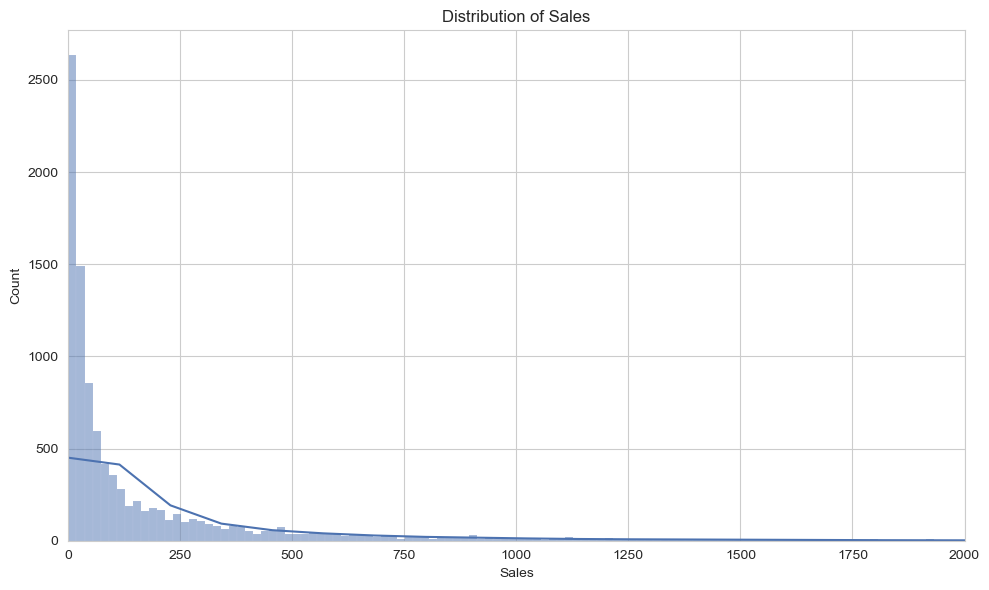

In [25]:
# 1. Sales distribution
fig, ax = plt.subplots()
sns.histplot(df["Sales"], bins="fd", kde=True, ax=ax, color="#4C72B0")
ax.set_title("Distribution of Sales")
ax.set_xlim(0, 2000)
save_and_show(fig, "01_sales_distribution")
plt.show()

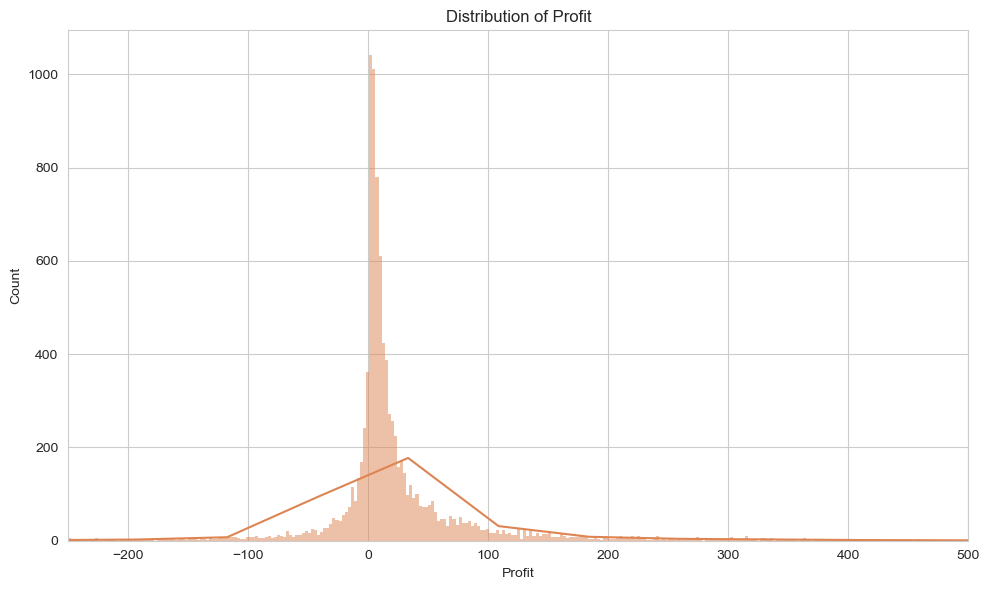

In [54]:
# 2. Profit distribution
fig, ax = plt.subplots()
sns.histplot(df["Profit"], bins="fd", kde=True, ax=ax, color="#DD8452")
ax.set_title("Distribution of Profit")
ax.set_xlim(-250, 500)
save_and_show(fig, "02_profit_distribution")
plt.show()

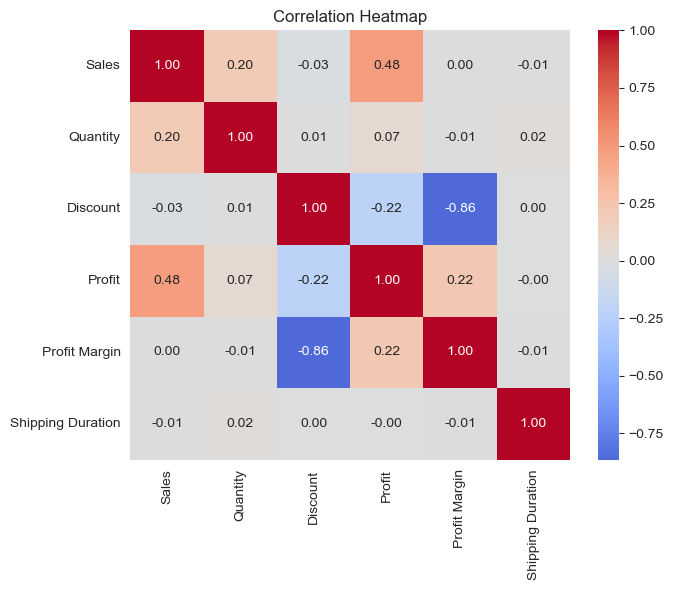

In [27]:
# 3. Correlation heatmap
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=ax, fmt=".2f")
ax.set_title("Correlation Heatmap")
save_and_show(fig, "03_correlation_heatmap")
plt.show()

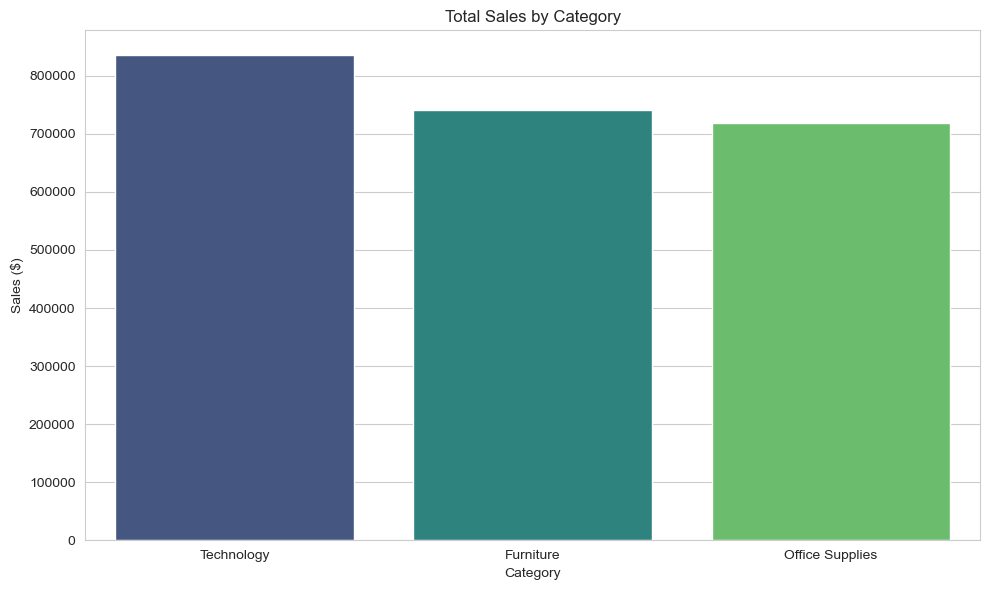

In [28]:
# 4. Sales by Category
fig, ax = plt.subplots()
cat_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
sns.barplot(x=cat_sales.index, y=cat_sales.values, ax=ax, hue=cat_sales.index, legend=False, palette="viridis")
ax.set_title("Total Sales by Category")
ax.set_ylabel("Sales ($)")
save_and_show(fig, "04_sales_by_category")
plt.show()

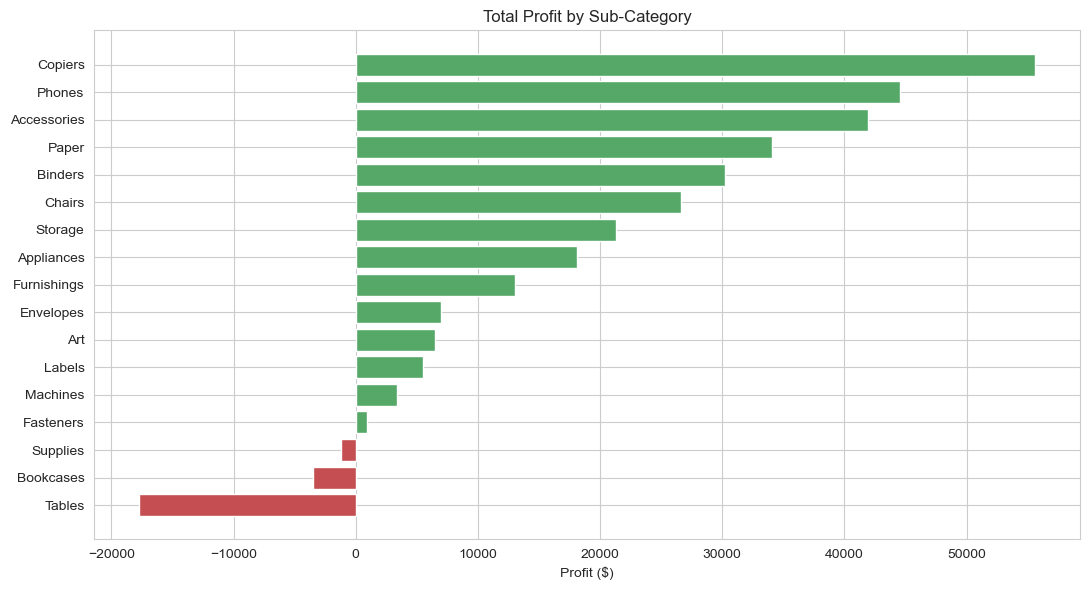

In [29]:
# 5. Profit by Sub-Category
fig, ax = plt.subplots(figsize=(11, 6))
sub_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()
colors = ["#C44E52" if v < 0 else "#55A868" for v in sub_profit.values]
ax.barh(sub_profit.index, sub_profit.values, color=colors)
ax.set_title("Total Profit by Sub-Category")
ax.set_xlabel("Profit ($)")
save_and_show(fig, "05_profit_by_subcategory")
plt.show()

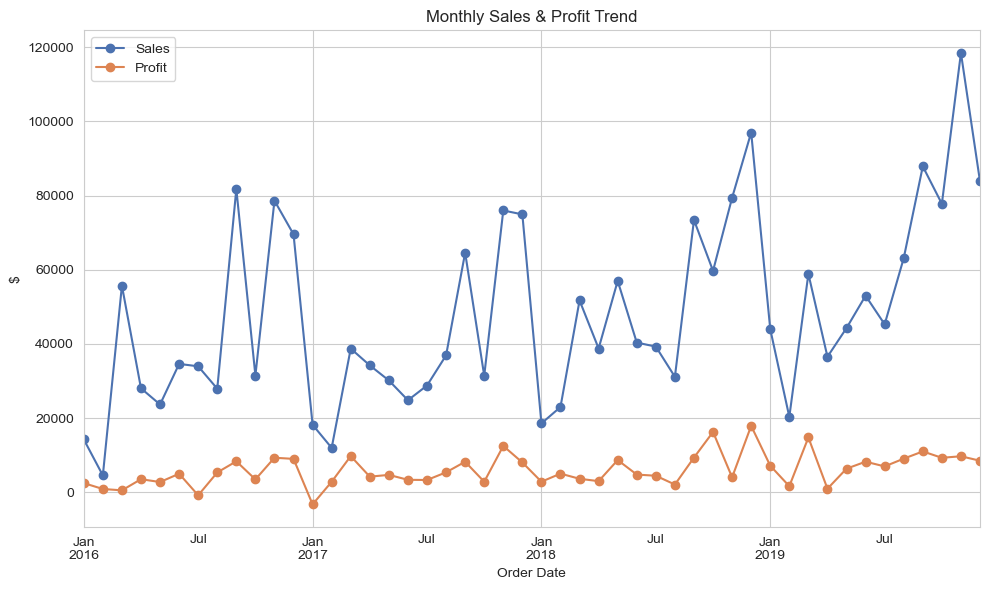

In [30]:
# 6. Sales trend over time
fig, ax = plt.subplots()
monthly["Sales"].plot(ax=ax, marker="o", color="#4C72B0", label="Sales")
monthly["Profit"].plot(ax=ax, marker="o", color="#DD8452", label="Profit")
ax.set_title("Monthly Sales & Profit Trend")
ax.set_ylabel("$")
ax.legend()
save_and_show(fig, "06_monthly_trend")
plt.show()

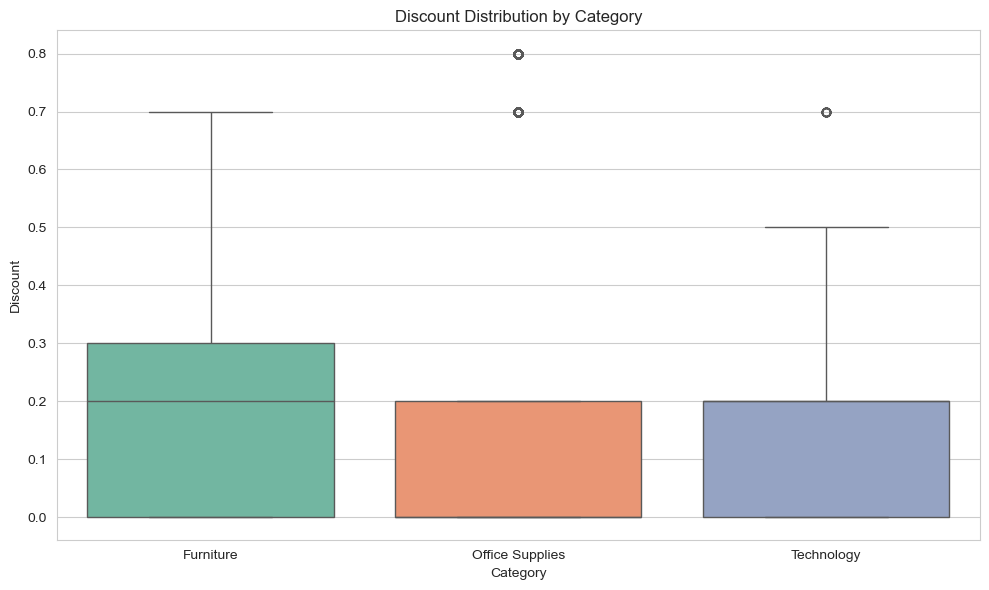

In [31]:
# 7. Discount distribution by Category (outliers)
fig, ax = plt.subplots()
sns.boxplot(data=df, x="Category", y="Discount", ax=ax, hue="Category", legend=False, palette="Set2")
ax.set_title("Discount Distribution by Category")
save_and_show(fig, "07_discount_by_category")
plt.show()

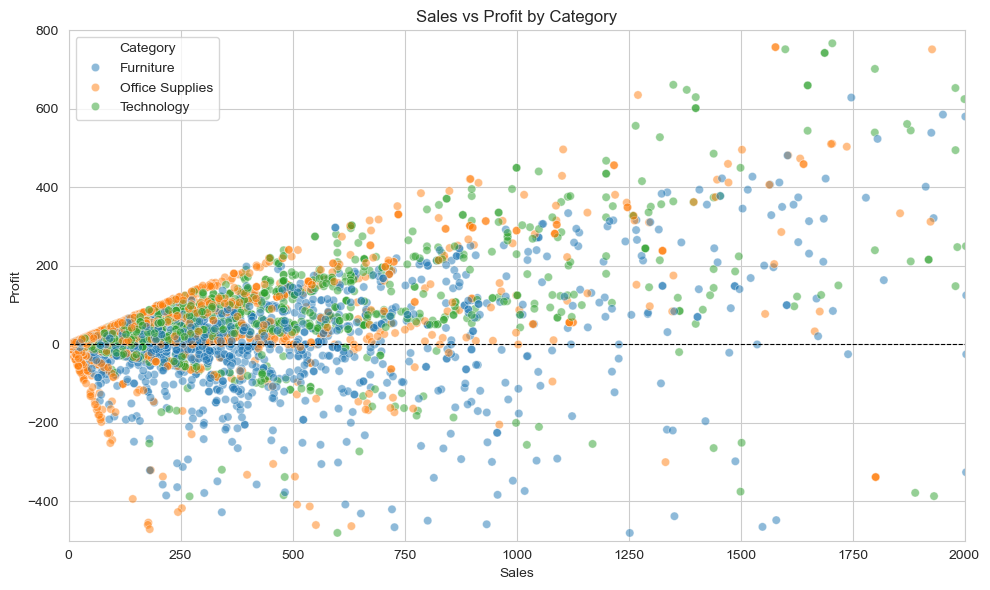

In [32]:
# 8. Sales vs Profit scatter
fig, ax = plt.subplots()
sns.scatterplot(data=df, x="Sales", y="Profit", hue="Category", alpha=0.5, ax=ax)
ax.set_xlim(0, 2000)
ax.set_ylim(-500, 800)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Sales vs Profit by Category")
save_and_show(fig, "08_sales_vs_profit")
plt.show()

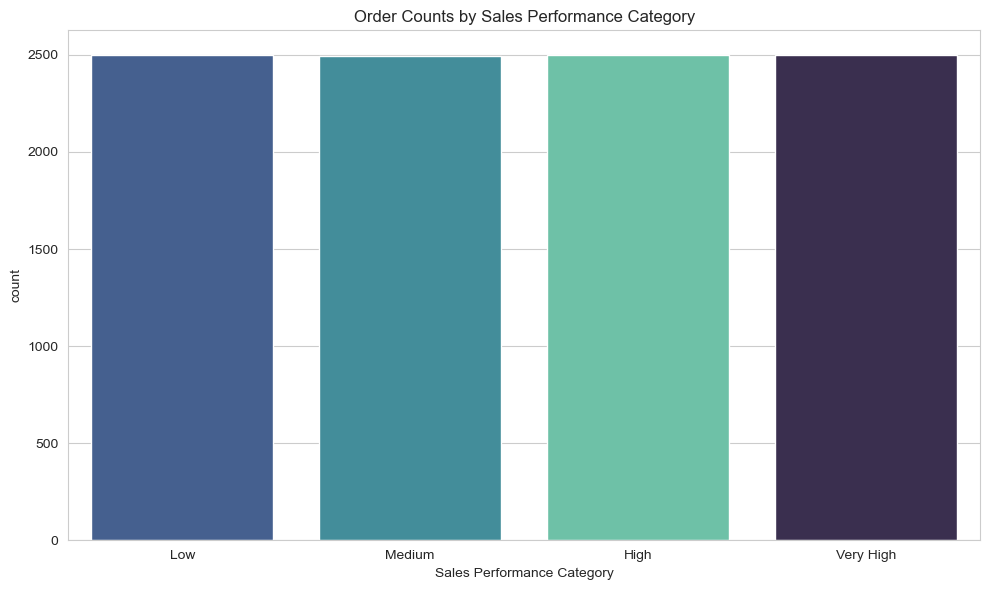

In [33]:
# 9. Sales Performance Category counts
fig, ax = plt.subplots()
order = ["Low", "Medium", "High", "Very High"]
sns.countplot(data=df, x="Sales Performance Category", order=order, hue="Sales Performance Category", legend=False, palette="mako", ax=ax)
ax.set_title("Order Counts by Sales Performance Category")
save_and_show(fig, "09_sales_performance_category")
plt.show()

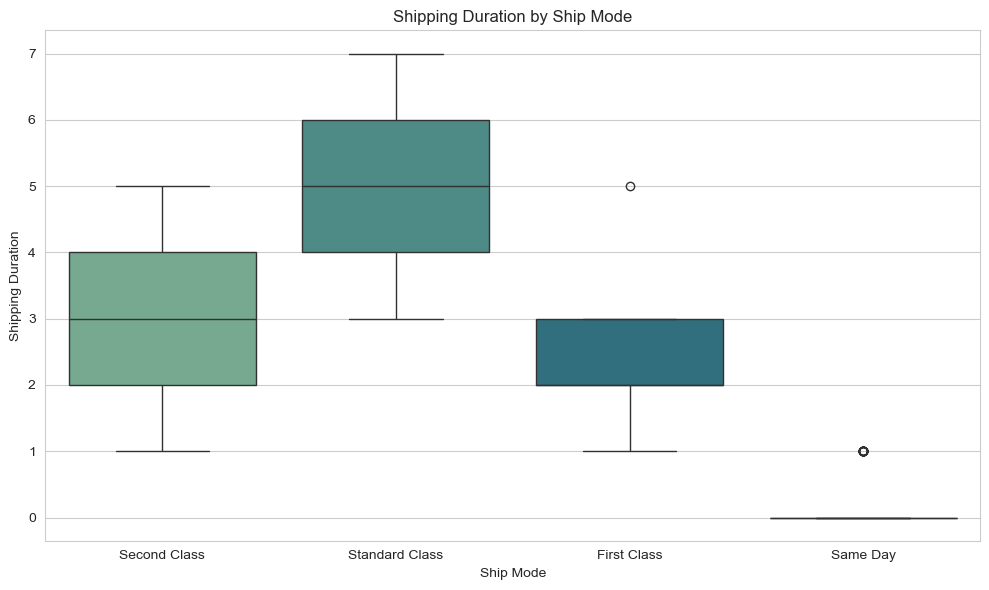

In [34]:
# 10. Shipping duration by Ship Mode
fig, ax = plt.subplots()
sns.boxplot(data=df, x="Ship Mode", y="Shipping Duration", ax=ax, hue="Ship Mode", legend=False, palette="crest")
ax.set_title("Shipping Duration by Ship Mode")
save_and_show(fig, "10_shipping_duration_by_mode")
plt.show()

## 9. Automated KPI Summary & Report Generation

In [35]:
report = kpi_summary(df)
print("=== Automated KPI Summary ===")
for k, v in report.items():
    print(f"{k}: {v}")

top_subcat = top_n(df, "Sub-Category", n=3, value="Sales")
worst_subcat = top_n(df, "Sub-Category", n=3, value="Profit", ascending=True)
best_region = segment_performance(df, "Region").index[0]

report["Top 3 Sub-Categories by Sales"] = top_subcat.round(2).to_dict()
report["3 Least Profitable Sub-Categories"] = worst_subcat.round(2).to_dict()
report["Best Performing Region"] = best_region
report

=== Automated KPI Summary ===
Total Sales: 2296919.49
Total Profit: 286409.08
Overall Profit Margin %: 12.47
Total Orders: 5009
Total Customers: 793
Avg Order Value: 458.56
Avg Discount: 0.156
Avg Shipping Duration (days): 3.96


{'Total Sales': 2296919.49,
 'Total Profit': 286409.08,
 'Overall Profit Margin %': 12.47,
 'Total Orders': 5009,
 'Total Customers': 793,
 'Avg Order Value': 458.56,
 'Avg Discount': 0.156,
 'Avg Shipping Duration (days)': 3.96,
 'Top 3 Sub-Categories by Sales': {'Phones': 330007.05,
  'Chairs': 328167.73,
  'Storage': 223843.61},
 '3 Least Profitable Sub-Categories': {'Tables': -17725.48,
  'Bookcases': -3472.56,
  'Supplies': -1189.1},
 'Best Performing Region': 'West'}

In [36]:
with open("kpi_summary.json", "w") as f:
    json.dump(report, f, indent=2, default=str)
print("KPI summary exported to kpi_summary.json")

KPI summary exported to kpi_summary.json


## 10. Export Cleaned Dataset & Visual Reports

In [37]:
df.to_parquet("Sample_Superstore_2019_Clean.parquet", index=False, engine='pyarrow')
print(f"Cleaned dataset exported: cleaned_superstore.parquet ({df.shape[0]} rows, {df.shape[1]} cols)")

print("Visualizations exported to ./figs/ (10 PNG files)")
print(sorted(os.listdir("figs")))

Cleaned dataset exported: cleaned_superstore.parquet (9993 rows, 24 cols)
Visualizations exported to ./figs/ (10 PNG files)
['01_sales_distribution.png', '02_profit_distribution.png', '03_correlation_heatmap.png', '04_sales_by_category.png', '05_profit_by_subcategory.png', '06_monthly_trend.png', '07_discount_by_category.png', '08_sales_vs_profit.png', '09_sales_performance_category.png', '10_shipping_duration_by_mode.png']


## 11. DataFrame Optimization (Memory Usage)

In [38]:
# Downcasts numeric dtypes and converts low-cardinality object columns to category.
def optimize_memory(data):
    out = data.copy()
    before_mb = out.memory_usage(deep=True).sum() / 1024**2
    for c in out.select_dtypes(include=["int64"]).columns:
        out[c] = pd.to_numeric(out[c], downcast="integer")
    for c in out.select_dtypes(include=["float64"]).columns:
        out[c] = pd.to_numeric(out[c], downcast="float")
    for c in out.select_dtypes(include="object").columns:
        if out[c].nunique() / len(out) < 0.5:
            out[c] = out[c].astype("category")
    after_mb = out.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage: {before_mb:.2f} MB -> {after_mb:.2f} MB ({(1 - after_mb/before_mb)*100:.1f}% reduction)")
    return out

df_optimized = optimize_memory(df)
df_optimized.dtypes

Memory usage: 3.66 MB -> 1.02 MB (72.2% reduction)


Order ID                                 str
Order Date                    datetime64[us]
Ship Date                     datetime64[us]
Ship Mode                           category
Customer ID                         category
Customer Name                       category
Segment                             category
Country/Region                      category
City                                category
State                               category
Postal Code                         category
Region                              category
Product ID                          category
Category                            category
Sub-Category                        category
Product Name                        category
Sales                                float64
Quantity                                int8
Discount                             float32
Profit                               float32
Profit Margin                        float32
Shipping Duration                       int8
Order Quar

## 12. Business Questions — Answered

Each question below is answered directly from the cleaned, feature-engineered dataset using the modular functions defined earlier.

### Sales Analysis

**Q1. What are the total sales and total profit generated by the business?**

In [39]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
print(f"Total Sales:  ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Profit Margin: {total_profit/total_sales*100:.2f}%")

Total Sales:  $2,296,919.49
Total Profit: $286,409.08
Overall Profit Margin: 12.47%


**Q2. Which product categories and sub-categories generate the highest and lowest sales?**

In [40]:
print("Category sales (highest to lowest):")
print(df.groupby("Category")["Sales"].sum().sort_values(ascending=False).round(2))
print()
print("Highest-selling sub-category:")
print(top_n(df, "Sub-Category", n=1, value="Sales"))
print()
print("Lowest-selling sub-category:")
print(top_n(df, "Sub-Category", n=1, value="Sales", ascending=True))

Category sales (highest to lowest):
Category
Technology         836154.03
Furniture          741718.42
Office Supplies    719047.03
Name: Sales, dtype: float64

Highest-selling sub-category:
Sub-Category
Phones    330007.054
Name: Sales, dtype: float64

Lowest-selling sub-category:
Sub-Category
Fasteners    3024.28
Name: Sales, dtype: float64


**Q3. What are the top-performing and worst-performing products based on sales revenue?**

In [41]:
print("Top 5 products by sales:")
print(top_n(df, "Product Name", n=5, value="Sales"))
print()
print("Bottom 5 products by sales:")
print(top_n(df, "Product Name", n=5, value="Sales", ascending=True))

Top 5 products by sales:
Product Name
Canon Imageclass 2200 Advanced Copier                                          61599.824
Fellowes Pb500 Electric Punch Plastic Comb Binding Machine With Manual Bind    27453.384
Cisco Telepresence System Ex90 Videoconferencing Unit                          22638.480
Hon 5400 Series Task Chairs For Big And Tall                                   21870.576
Gbc Docubind Tl300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

Bottom 5 products by sales:
Product Name
Eureka Disposable Bags For Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Name: Sales, dtype: float64


**Q4. How do sales and profits change over time across months and quarters?**

In [42]:
print("=== Monthly trend (first 6 months) ===")
print(monthly.head(6).round(2))
print()
quarterly = df.groupby("Order Quarter")[["Sales", "Profit"]].sum()
print("=== Quarterly trend ===")
quarterly.round(2)

=== Monthly trend (first 6 months) ===
               Sales   Profit
Order Date                   
2016-01-31  14236.90  2450.19
2016-02-29   4519.89   862.31
2016-03-31  55691.01   498.73
2016-04-30  28013.97  3500.89
2016-05-31  23648.29  2738.71
2016-06-30  34595.13  4976.52

=== Quarterly trend ===


,Sales,Profit
Order Quarter,,
2016Q1,74447.80,3811.23
2016Q2,86257.39,11216.13
2016Q3,143633.21,12804.72
2016Q4,179627.73,21723.95
2017Q1,68851.74,9264.94
2017Q2,89124.19,12190.92
2017Q3,130259.58,16853.62
2017Q4,182297.01,23309.12
2018Q1,93237.18,11441.37


**Q5. Which regions and states contribute the most and least to overall sales?**

In [43]:
print("=== By Region ===")
print(segment_performance(df, "Region")[["Sales", "Profit"]])
print()
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)
print("Top 5 states by sales:")
print(state_sales.head(5).round(2))
print()
print("Bottom 5 states by sales:")
print(state_sales.tail(5).round(2))

=== By Region ===
               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678499.8680   91534.8388
Central  501239.8908   39706.3625
South    391721.9050   46749.4303

Top 5 states by sales:
State
California      457687.63
New York        310876.27
Texas           170188.05
Washington      138641.27
Pennsylvania    116511.91
Name: Sales, dtype: float64

Bottom 5 states by sales:
State
Wyoming          1603.14
South Dakota     1315.56
Maine            1270.53
West Virginia    1209.82
North Dakota      919.91
Name: Sales, dtype: float64


### Profitability Analysis

**Q6. Which categories, sub-categories, and products are the most profitable?**

In [44]:
print("Most profitable category:")
print(df.groupby("Category")["Profit"].sum().sort_values(ascending=False).head(1))
print()
print("Most profitable sub-category:")
print(top_n(df, "Sub-Category", n=1, value="Profit"))
print()
print("Most profitable product:")
print(top_n(df, "Product Name", n=1, value="Profit"))

Most profitable category:
Category
Technology    145454.9481
Name: Profit, dtype: float64

Most profitable sub-category:
Sub-Category
Copiers    55617.8249
Name: Profit, dtype: float64

Most profitable product:
Product Name
Canon Imageclass 2200 Advanced Copier    25199.928
Name: Profit, dtype: float64


**Q7. Are there products with high sales volume but low or negative profitability?**

In [45]:
product_stats = df.groupby("Product Name").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum")).reset_index()
high_sales_threshold = product_stats["Sales"].quantile(0.75)
flagged = product_stats[(product_stats["Sales"] >= high_sales_threshold) & (product_stats["Profit"] <= 0)]
print(f"Products in the top sales quartile (>= ${high_sales_threshold:,.0f}) with zero/negative profit: {len(flagged)}")
flagged.sort_values("Sales", ascending=False).head(10)

Products in the top sales quartile (>= $1,206) with zero/negative profit: 125


,Product Name,Sales,Profit
444,Cisco Telepresence System Ex90 Videoconferenci...,22638.4800,-1811.0784
683,Gbc Docubind P400 Electric Binding System,17965.0680,-1878.1662
805,High Speed Automatic Electric Letter Opener,17030.3120,-262.0048
987,Lexmark Mx611Dhe Monochrome Laser Printer,16829.9010,-4589.9730
1049,Martin Yale Chadless Opener Electric Letter Op...,16656.2000,-1299.1836
1357,"Riverside Palais Royal Lawyers Bookcase, Royal...",15610.9656,-669.5448
368,Bretford Rectangular Conference Table Tops,12995.2915,-327.2331
475,Cubify Cubex 3D Printer Double Head Print,11099.9630,-8879.9704
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.6400,-2876.1156
376,Bush Advantage Collection Racetrack Conference...,9544.7250,-1934.3976


**Q8. What is the relationship between discount rates and profit?**

In [46]:
print(f"Correlation between Discount and Profit: {df['Discount'].corr(df['Profit']):.3f}")
print()
discount_bins = pd.cut(df["Discount"], bins=[-0.01, 0, 0.2, 0.4, 0.6, 1.0])
print("Average profit by discount band:")
df.groupby(discount_bins, observed=True)["Profit"].mean().round(2)

Correlation between Discount and Profit: -0.219

Average profit by discount band:


Discount
(-0.01, 0.0]     66.90
(0.0, 0.2]       26.50
(0.2, 0.4]      -78.01
(0.4, 0.6]     -134.62
(0.6, 1.0]      -98.35
Name: Profit, dtype: float64

**Q9. Which customer segment generates the highest profit & profit margin?**

In [47]:
segment_performance(df, "Segment")[["Sales", "Profit", "Profit Margin %"]]

,Sales,Profit,Profit Margin %
Segment,,,
Consumer,1.161401e+06,134119.2092,11.55
Corporate,7.061464e+05,91979.1340,13.03
Home Office,4.293718e+05,60310.7373,14.05


### Customer Analysis

**Q10. Who are the top customers by sales and profitability?**

In [48]:
print("Top 5 customers by sales:")
print(top_n(df, "Customer Name", n=5, value="Sales"))
print()
print("Top 5 customers by profit:")
print(top_n(df, "Customer Name", n=5, value="Profit"))

Top 5 customers by sales:
Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64

Top 5 customers by profit:
Customer Name
Tamara Chand     8981.3239
Raymond Buch     6976.0959
Sanjit Chand     5757.4119
Hunter Lopez     5622.4292
Adrian Barton    5444.8055
Name: Profit, dtype: float64


**Q11. How are sales distributed across different customer segments?**

In [49]:
segment_share = df.groupby("Segment")["Sales"].sum()
segment_share_pct = (segment_share / segment_share.sum() * 100).round(2)
segment_share_pct.sort_values(ascending=False)

Segment
Consumer       50.56
Corporate      30.74
Home Office    18.69
Name: Sales, dtype: float64

**Q12. Is a small group of customers responsible for a large percentage of total sales and profit (Pareto Analysis)?**

In [50]:
sales_share, n_top, n_total = pareto_share(df, "Customer ID", value="Sales", top_pct=0.20)
profit_share, _, _ = pareto_share(df, "Customer ID", value="Profit", top_pct=0.20)
print(f"Top 20% of customers ({n_top} of {n_total}) account for {sales_share}% of total sales and {profit_share}% of total profit.")

Top 20% of customers (158 of 793) account for 47.96% of total sales and 81.42% of total profit.


### Operational Analysis

**Q13. What is the average shipping duration for each shipping mode?**

In [51]:
df.groupby("Ship Mode")["Shipping Duration"].mean().round(2).sort_values()

Ship Mode
Same Day          0.04
First Class       2.18
Second Class      3.24
Standard Class    5.01
Name: Shipping Duration, dtype: float64

**Q14. Does shipping duration have an impact on sales performance and profitability?**

In [52]:
print(f"Correlation between Shipping Duration and Sales:  {df['Shipping Duration'].corr(df['Sales']):.3f}")
print(f"Correlation between Shipping Duration and Profit: {df['Shipping Duration'].corr(df['Profit']):.3f}")
print()
df.groupby("Sales Performance Category")["Shipping Duration"].mean().reindex(["Low", "Medium", "High", "Very High"]).round(2)

Correlation between Shipping Duration and Sales:  -0.007
Correlation between Shipping Duration and Profit: -0.005



Sales Performance Category
Low          3.96
Medium       4.01
High         3.93
Very High    3.93
Name: Shipping Duration, dtype: float64

**Q15. Which variables have the strongest influence on profit according to correlation analysis?**

In [53]:
profit_corr = corr["Profit"].drop("Profit").sort_values(key=abs, ascending=False)
profit_corr.round(3)

Sales                0.479
Profit Margin        0.224
Discount            -0.219
Quantity             0.066
Shipping Duration   -0.005
Name: Profit, dtype: float64

## Conclusion

The pipeline above ingests raw Superstore order data, cleans and validates it, engineers analytical features (Profit Margin, Shipping Duration, Order Quarter, Sales Performance Category), and produces 10 charts plus an automated KPI report. Section 12 directly answers the 15 business questions covering sales, profitability, customer, and operational performance. Cleaned data (`cleaned_superstore.parque`), the KPI report (`kpi_summary.json`), and all chart images (`figs/`) are exported for downstream use (e.g., BI dashboards).